# EDA — eksploracyjna analiza danych

Projekt dotyczy analizy komentarzy użytkowników Reddita w wybranych społecznościach muzycznych. Celem notebooka jest uporządkowanie danych wejściowych, opisanie podstawowych cech zbioru oraz wskazanie różnic między subredditami przed przejściem do analizy text mining i analizy sieci społecznościowych.


## 1. Opis zbioru danych

Dane wykorzystane w projekcie pochodzą z Reddit API i obejmują komentarze z czterech społeczności muzycznych: `r/hiphopheads`, `r/indieheads`, `r/Metal` oraz `r/popheads`. Zbiór obejmuje okres od 11 marca 2020 r. do 11 marca 2021 r.

Analiza EDA ma na celu:

- określenie wielkości i struktury zbioru danych,
- sprawdzenie liczby komentarzy i aktywności użytkowników w poszczególnych subredditach,
- porównanie długości komentarzy oraz poziomu zaangażowania,
- przygotowanie oczyszczonego zbioru do dalszej analizy tekstowej i sieciowej.


In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Ustawienia wizualizacji
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# Mapowanie nazw subredditów na etykiety do prezentacji (bez zmiany danych w kolumnie `subreddit`)
SUBREDDIT_LABELS = {
    "Metal": "Metal",
    "hiphopheads": "Hip-hop",
    "popheads": "Pop",
    "indieheads": "Indie",
}


def subreddit_display(name: str) -> str:
    return SUBREDDIT_LABELS.get(str(name), str(name))


# Sciezki projektu - notebook zaklada typowa strukture: /notebooks, /data, /outputs
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"
CHECKPOINT_DIR = DATA_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "processed" / "all_subreddits_sample.csv"
CLEAN_DATA_PATH = DATA_DIR / "processed" / "all_subreddits_clean.csv"

print(f"Wczytywany plik: {DATA_PATH}")

Wczytywany plik: ..\data\processed\all_subreddits_sample.csv


In [14]:
df_raw = pd.read_csv(DATA_PATH)

# Ujednolicenie nazw kolumn, jeśli w danych występują warianty nazw
if "id" in df_raw.columns and "comment_id" not in df_raw.columns:
    df_raw = df_raw.rename(columns={"id": "comment_id"})

required_columns = {"subreddit", "author", "body", "created_utc"}
missing_columns = required_columns - set(df_raw.columns)
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

print(f"Liczba rekordów przed czyszczeniem: {len(df_raw):,}")
display(df_raw.head())


Liczba rekordów przed czyszczeniem: 2,544,183


,comment_id,author,body,subreddit,score,created_utc,parent_id,link_id,controversiality,gilded
0,fk5omrz,Moron_on_Oxy-,Read that Baby Keem had a few tweets complaini...,hiphopheads,2,1583884815,t3_fglr4p,t3_fglr4p,0,0
1,fk5ono1,superchingonguey,Yeah I stumbled upon her about a year ago. She...,hiphopheads,2,1583884830,t1_fk5o56t,t3_fgnnun,0,0
2,fk5osck,Aniceguy96,"For sure Billy has more energy, Ka puts me to ...",hiphopheads,1,1583884906,t1_fk5mi66,t3_fglr4p,0,0
3,fk5oslg,Sushieatinbeast,Passion of the weiss is for the culture. I've ...,hiphopheads,20,1583884910,t3_fgihaz,t3_fgihaz,0,0
4,fk5ourg,DocterJohnSmith,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...",hiphopheads,2,1583884946,t1_fk5o548,t3_fglr4p,0,0


## 2. Czyszczenie danych

Na początku analizy usunięto rekordy, które mogłyby zaburzać wyniki: komentarze usunięte przez użytkowników lub moderatorów oraz konta botów. Dzięki temu wszystkie dalsze statystyki odnoszą się do tego samego, oczyszczonego zbioru danych.


In [15]:
df = df_raw.copy()

# Rozszerzona lista botów i kont technicznych
BOTS = {
    "MusicMirrorMan",
    "HHHRobot",
    "NoGoogleAMPBot",
    "ReconEG",
    "AutoModerator",
    "RemindMeBot",
    "SaveVideoBot",
    "DownloadVideoBot",
    "LinkifyBot",
    "auddbot",
    "songbot",
    "lyricsbot",
    "MusicIdentifierBot",
    "SpotifyPreviewBot",
    "RepostSleuthBot",
    "MAGIC_EYE_BOT",
    "DuplicateDestroyer",
    "GrammarBotElite",
    "ShakespeareBot",
    "WikipediaSummaryBot",
    "HelpfulBot",
    "AssistantBot",
    "FreshReleaseBot",
    "AlbumDropBot",
    "TrackReleaseBot",
    "MusicNewsBot",
    "HipHopBot",
    "IndieBot",
    "PopMusicBot",
    "TwitterStatusBot",
    "YouTubeBot",
    "RedditVideoBot",
    "TotesMessenger",
    "AntiSpamBot",
    "BotDefense",
    "autotldr",
    "tweettranscriberbot",
    "transcribersofreddit",
}

# Uzupełnienie braków
df["body"] = df["body"].fillna("").astype(str)
df["author"] = df["author"].fillna("unknown").astype(str)

# Usuwanie pustych i technicznych komentarzy
body_clean = df["body"].str.strip()

removed_comment_mask = body_clean.str.lower().isin([
    "[deleted]",
    "[removed]",
    "deleted",
    "removed",
    ""
])

# Usuwanie botów i kont technicznych
author_clean = df["author"].str.strip()

bot_mask = (
    author_clean.isin(BOTS)
    | author_clean.str.lower().str.contains("bot", na=False)
    | author_clean.str.lower().isin([
        "[deleted]",
        "deleted",
        "automoderator"
    ])
)

# Dodatkowe wiadomości moderacyjne
moderation_patterns = [
    r"hello, thanks for posting",
    r"your submission has been removed",
    r"this post has been removed",
    r"please contact the moderators",
    r"i am a bot",
    r"beep boop",
]

moderation_mask = df["body"].str.contains(
    "|".join(moderation_patterns),
    case=False,
    na=False,
    regex=True
)

# Podsumowanie czyszczenia
cleaning_summary = pd.DataFrame({
    "kategoria": [
        "rekordy początkowe",
        "komentarze usunięte",
        "boty i konta techniczne",
        "wiadomości moderacyjne",
        "rekordy po czyszczeniu"
    ],
    "liczba": [
        len(df),
        int(removed_comment_mask.sum()),
        int(bot_mask.sum()),
        int(moderation_mask.sum()),
        int(
            (
                ~removed_comment_mask
                & ~bot_mask
                & ~moderation_mask
            ).sum()
        )
    ]
})

# Filtrowanie danych
df = df.loc[
    ~removed_comment_mask
    & ~bot_mask
    & ~moderation_mask
].copy()

# Daty i zmienne pomocnicze

df["date"] = pd.to_datetime(
    pd.to_numeric(
        df["created_utc"],
        errors="coerce"
    ),
    unit="s",
    errors="coerce"
)

df = df.dropna(subset=["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M")

df["body_len"] = (
    df["body"]
    .astype(str)
    .str.len()
)

df["word_count"] = (
    df["body"]
    .astype(str)
    .str.split()
    .str.len()
)

# Zapis oczyszczonych danych

df.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

# Podsumowanie

cleaning_summary.to_csv(
    REPORTS_DIR / "eda_cleaning_summary.csv",
    index=False
)

display(cleaning_summary)

print(
    f"Liczba rekordów po czyszczeniu: {len(df):,}"
)

print(
    f"Zapisano oczyszczone dane do:\n{CLEAN_DATA_PATH}"
)

,kategoria,liczba
0,rekordy początkowe,2544183
1,komentarze usunięte,0
2,boty i konta techniczne,44569
3,wiadomości moderacyjne,41475
4,rekordy po czyszczeniu,2492764


Liczba rekordów po czyszczeniu: 2,492,764
Zapisano oczyszczone dane do:
..\data\processed\all_subreddits_clean.csv


Komentarze techniczne i automatyczne mogą sztucznie zwiększać aktywność wybranych społeczności, dlatego zostały usunięte przed obliczeniem statystyk. Taki zabieg poprawia porównywalność subredditów i zmniejsza ryzyko, że wyniki będą opisywać pracę botów, a nie zachowania użytkowników.


## 3. Struktura zbioru według subredditów

Poniższa tabela pokazuje podstawowy rozkład komentarzy między społecznościami. Oprócz liczby komentarzy uwzględniono udział procentowy danego subreddita w zbiorze oraz średnią długość komentarza.


In [16]:
subreddit_summary = (
    df.groupby("subreddit")
    .agg(
        liczba_komentarzy=("body", "count"),
        unikalni_autorzy=("author", "nunique"),
        srednia_dlugosc_komentarza=("body_len", "mean"),
        mediana_dlugosci_komentarza=("body_len", "median"),
        srednia_liczba_slow=("word_count", "mean"),
    )
    .sort_values("liczba_komentarzy", ascending=False)
)
subreddit_summary["udzial_%"] = (
    subreddit_summary["liczba_komentarzy"] / subreddit_summary["liczba_komentarzy"].sum() * 100
)
subreddit_summary = subreddit_summary[
    [
        "liczba_komentarzy",
        "udzial_%",
        "unikalni_autorzy",
        "srednia_dlugosc_komentarza",
        "mediana_dlugosci_komentarza",
        "srednia_liczba_slow",
    ]
].round(2)

subreddit_summary.to_csv(REPORTS_DIR / "eda_subreddit_summary.csv")

# Podgląd do prezentacji: polskie nazwy społeczności; zapis CSV pozostaje techniczny
display(subreddit_summary.rename(index=SUBREDDIT_LABELS))

,liczba_komentarzy,udzial_%,unikalni_autorzy,srednia_dlugosc_komentarza,mediana_dlugosci_komentarza,srednia_liczba_slow
subreddit,,,,,,
Hip-hop,1262005,50.63,109727,139.98,80.0,25.50
Pop,761532,30.55,36974,200.41,110.0,35.89
Indie,363300,14.57,51371,180.75,105.0,31.93
Metal,105927,4.25,16982,187.12,106.0,31.55


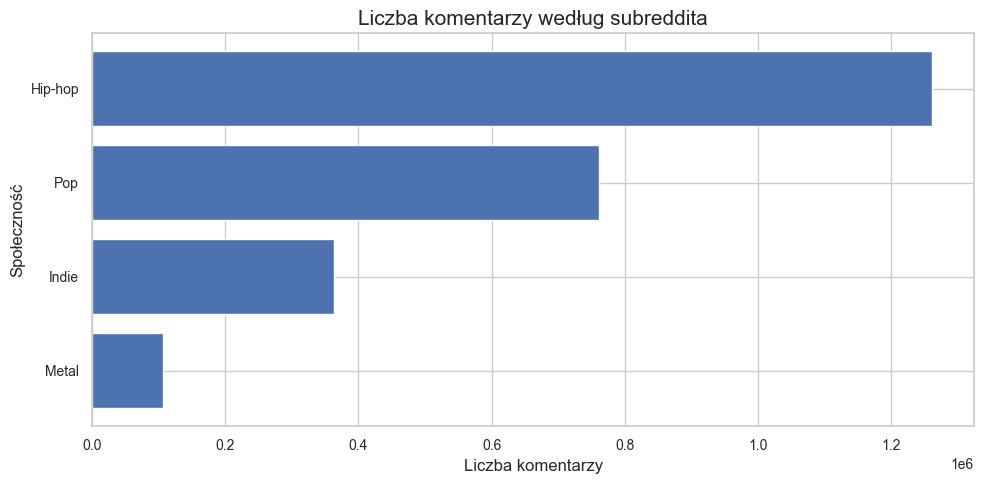

In [17]:
fig, ax = plt.subplots()
plot_data = subreddit_summary.reset_index().sort_values("liczba_komentarzy", ascending=True)
plot_data["subreddit_display"] = plot_data["subreddit"].map(SUBREDDIT_LABELS).fillna(plot_data["subreddit"])

ax.barh(plot_data["subreddit_display"], plot_data["liczba_komentarzy"])
ax.set_title("Liczba komentarzy według subreddita")
ax.set_xlabel("Liczba komentarzy")
ax.set_ylabel("Społeczność")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_comments_by_subreddit.png", dpi=150, bbox_inches="tight")
plt.show()

Wykres pokazuje wyraźne różnice w liczbie komentarzy między analizowanymi społecznościami. Największą aktywnością charakteryzował się Hip-hop, który zdecydowanie dominował pod względem liczby komentarzy. Pop również generował dużą liczbę dyskusji, natomiast Indie i szczególnie Metal były znacznie mniejszymi społecznościami. Oznacza to, że późniejsze wyniki analiz tekstowych i sieciowych mogą być częściowo kształtowane przez skalę aktywności poszczególnych subredditów, zwłaszcza w przypadku Hip-hopu i Popu.

## 4. Aktywność w czasie

Analiza aktywności miesięcznej pozwala sprawdzić, czy liczba komentarzy była stabilna, czy też występowały okresowe wzrosty aktywności. Takie zmiany mogą wynikać np. z premier albumów, wydarzeń branżowych, kontrowersji albo sezonowego wzrostu dyskusji.


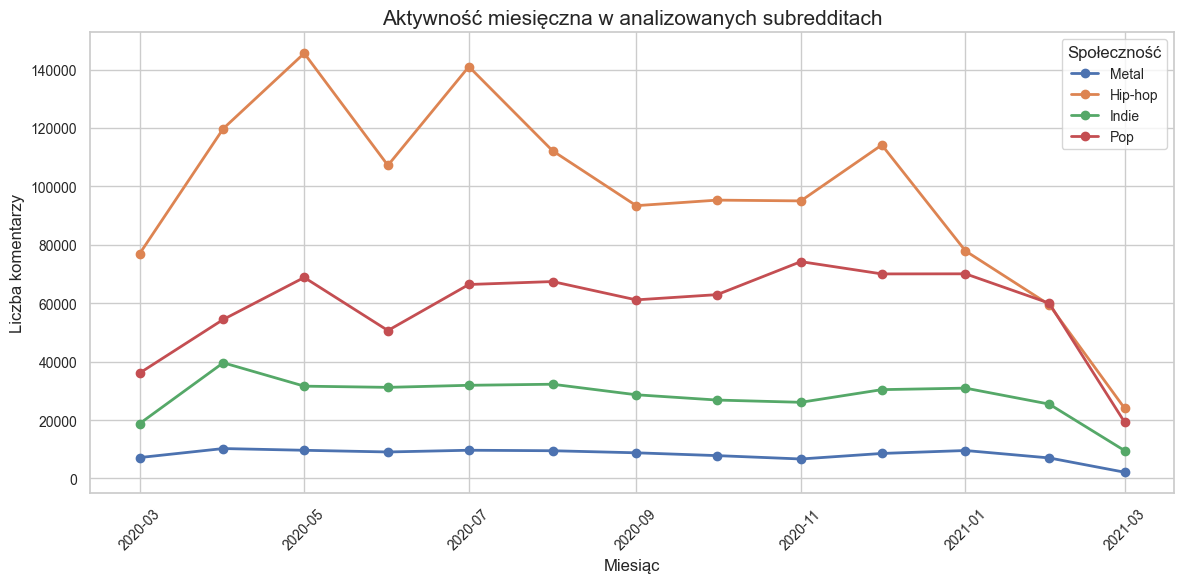

In [18]:
activity = (
    df.groupby(["subreddit", "month"])
    .size()
    .reset_index(name="liczba_komentarzy")
)
activity["month_ts"] = activity["month"].dt.to_timestamp()
activity.to_csv(REPORTS_DIR / "eda_monthly_activity.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
for sub, group in activity.groupby("subreddit"):
    group = group.sort_values("month_ts")
    ax.plot(
        group["month_ts"],
        group["liczba_komentarzy"],
        marker="o",
        linewidth=2,
        label=subreddit_display(sub),
    )

ax.set_title("Aktywność miesięczna w analizowanych subredditach")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Liczba komentarzy")
ax.legend(title="Społeczność")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_monthly_activity.png", dpi=150, bbox_inches="tight")
plt.show()

Wykres aktywności miesięcznej pokazuje, że wszystkie analizowane społeczności utrzymywały podobny ogólny trend zmian aktywności w czasie, jednak skala dyskusji była wyraźnie różna. Największą liczbę komentarzy przez większość okresu generował Hip-hop, natomiast Metal pozostawał najmniejszą społecznością. Widoczne są również okresowe wzrosty aktywności, szczególnie w Hip-hopie i Popie, co może być związane z premierami albumów, wydarzeniami muzycznymi lub zwiększoną aktywnością fanów w danym czasie.

## 5. Długość komentarzy

Długość komentarzy jest prostym wskaźnikiem charakteru dyskusji. Krótsze komentarze mogą sugerować bardziej reaktywny styl komunikacji, natomiast dłuższe wypowiedzi mogą wskazywać na bardziej opisowe, argumentacyjne lub recenzenckie rozmowy.


In [19]:
length_stats = (
    df.groupby("subreddit")["body_len"]
    .agg(srednia="mean", mediana="median", min="min", max="max", q95=lambda x: x.quantile(0.95))
    .round(1)
)
length_stats.to_csv(REPORTS_DIR / "eda_comment_length_stats.csv")
display(length_stats)


,srednia,mediana,min,max,q95
subreddit,,,,,
Metal,187.1,106.0,10,10086,598.7
hiphopheads,140.0,80.0,10,10081,442.0
indieheads,180.7,105.0,10,10017,562.0
popheads,200.4,110.0,10,10265,627.0


C:\Users\jaswe\AppData\Local\Temp\ipykernel_18904\453980993.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Społeczność")


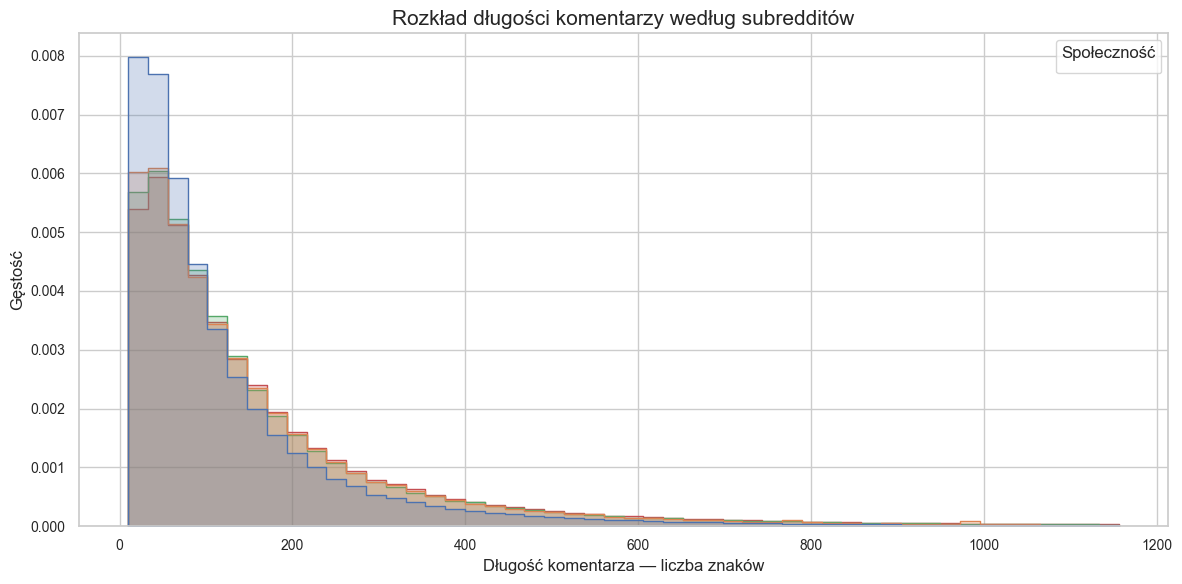

In [20]:
# Przycięcie do 99 percentyla poprawia czytelność wykresu, nie zmieniając głównej interpretacji rozkładu.
cutoff = df["body_len"].quantile(0.99)
plot_df = df.loc[df["body_len"] <= cutoff].copy()
plot_df["subreddit_display"] = plot_df["subreddit"].map(SUBREDDIT_LABELS).fillna(plot_df["subreddit"])

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    data=plot_df,
    x="body_len",
    hue="subreddit_display",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.set_title("Rozkład długości komentarzy według subredditów")
ax.set_xlabel("Długość komentarza — liczba znaków")
ax.set_ylabel("Gęstość")
ax.legend(title="Społeczność")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_comment_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Wykres pokazuje, że rozkłady długości komentarzy były bardzo podobne we wszystkich analizowanych społecznościach. Większość wypowiedzi miała stosunkowo krótką formę, natomiast bardzo długie komentarze pojawiały się rzadko. Można zauważyć, że Hip-hop i Pop częściej zawierały nieco dłuższe komentarze, podczas gdy Metal charakteryzował się bardziej zwartymi wypowiedziami. Ogólnie różnice między społecznościami były jednak niewielkie, co sugeruje podobny styl komunikacji pod względem długości komentarzy.

## 6. Wynik komentarzy i poziom zaangażowania

Wynik komentarza (`score`) może być traktowany jako przybliżony wskaźnik reakcji społeczności. Nie jest to jednak bezpośrednia miara jakości komentarza, ponieważ zależy od widoczności wpisu, czasu publikacji, popularności wątku oraz norm danej społeczności.


In [21]:
if "score" in df.columns:
    score_stats = (
        df.groupby("subreddit")["score"]
        .agg(
            srednia="mean",
            mediana="median",
            min="min",
            max="max",
            q95=lambda x: x.quantile(0.95),
        )
        .round(2)
    )
    score_stats.to_csv(REPORTS_DIR / "eda_score_stats.csv")

    # Podgląd do prezentacji: polskie nazwy społeczności; zapis CSV pozostaje techniczny
    display(score_stats.rename(index=SUBREDDIT_LABELS))
else:
    display(
        Markdown(
            "W zbiorze danych nie ma kolumny `score`, dlatego pominięto analizę wyników komentarzy."
        )
    )

,srednia,mediana,min,max,q95
subreddit,,,,,
Metal,4.45,2.0,-238,833,15.0
Hip-hop,18.69,3.0,-530,12007,65.0
Indie,9.36,3.0,-336,1802,33.0
Pop,21.51,7.0,-261,3630,83.0


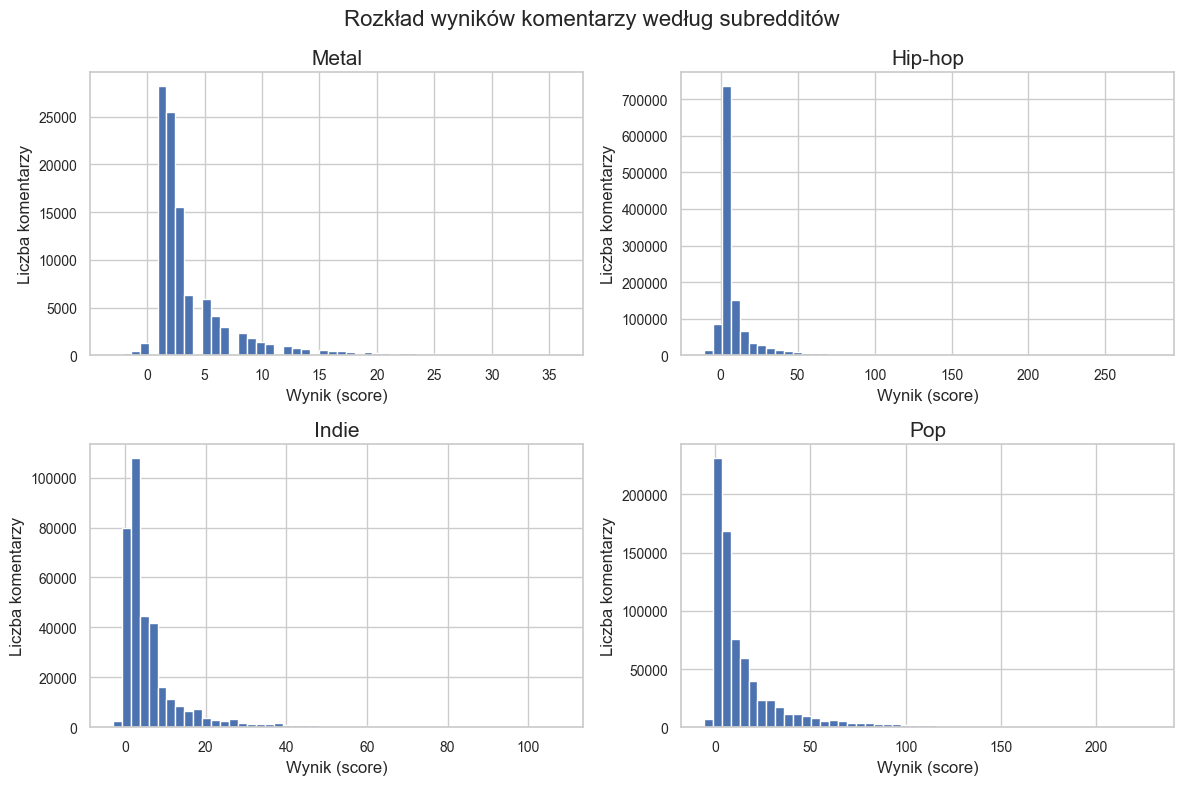

In [22]:
if "score" in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, (sub, group) in enumerate(df.groupby("subreddit")):
        low = group["score"].quantile(0.01)
        high = group["score"].quantile(0.99)
        data = group.loc[(group["score"] >= low) & (group["score"] <= high), "score"]
        axes[i].hist(data, bins=50)
        axes[i].set_title(subreddit_display(sub))
        axes[i].set_xlabel("Wynik (score)")
        axes[i].set_ylabel("Liczba komentarzy")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Rozkład wyników komentarzy według subredditów", fontsize=16)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "eda_score_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

Wykres pokazuje, że w każdej społeczności większość komentarzy uzyskiwała stosunkowo niski wynik score, natomiast bardzo wysoko oceniane wypowiedzi pojawiały się znacznie rzadziej. Rozkłady były silnie prawostronnie skośne, co oznacza obecność niewielkiej liczby komentarzy osiągających bardzo dużą popularność. Największe wartości score widoczne były szczególnie w społecznościach Hip-hop oraz Pop, co może wynikać z większej aktywności użytkowników i szybszego rozpowszechniania popularnych dyskusji. Metal charakteryzował się natomiast bardziej zwartym rozkładem i mniejszą liczbą skrajnie wysoko ocenianych komentarzy.

## 7. Najaktywniejsi autorzy

Analiza najaktywniejszych autorów pozwala ocenić, czy dyskusje są rozproszone między wielu użytkowników, czy zdominowane przez niewielką grupę bardzo aktywnych kont.


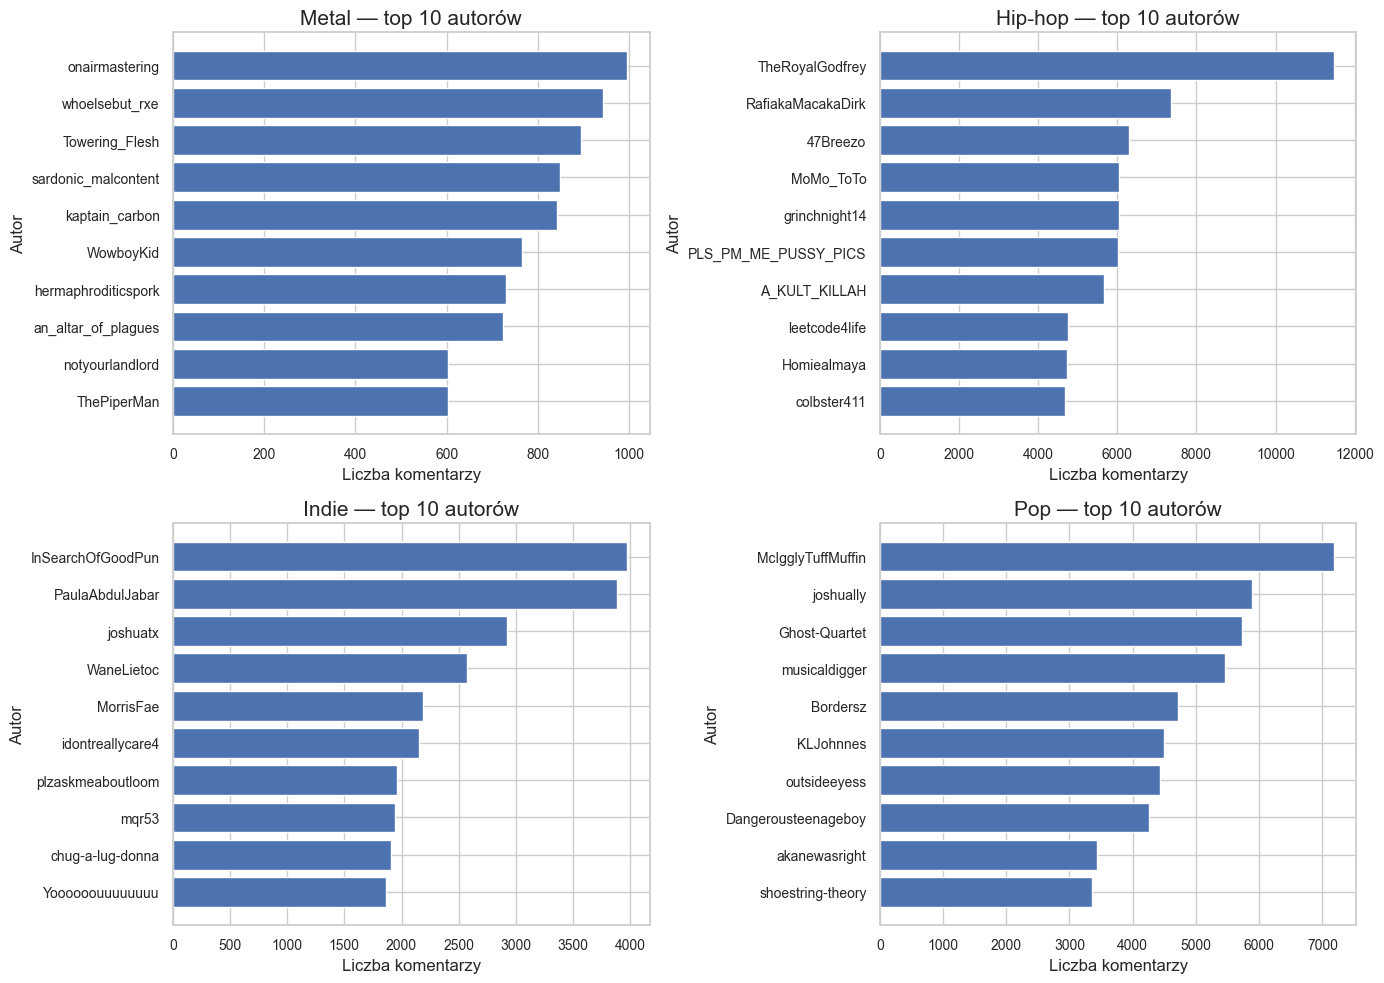

,subreddit,author,liczba_komentarzy
0,Metal,onairmastering,995
1,Metal,whoelsebut_rxe,942
2,Metal,Towering_Flesh,895
3,Metal,sardonic_malcontent,849
4,Metal,kaptain_carbon,841
5,Metal,WowboyKid,766
6,Metal,hermaphroditicspork,731
7,Metal,an_altar_of_plagues,723
8,Metal,notyourlandlord,604
9,Metal,ThePiperMan,603


In [23]:
top_authors_tables = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    top = group["author"].value_counts().head(10)
    top_table = top.rename_axis("author").reset_index(name="liczba_komentarzy")
    top_table.insert(0, "subreddit", sub)
    top_authors_tables.append(top_table)

    axes[i].barh(top.index[::-1], top.values[::-1])
    axes[i].set_title(f"{subreddit_display(sub)} — top 10 autorów")
    axes[i].set_xlabel("Liczba komentarzy")
    axes[i].set_ylabel("Autor")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_top_authors.png", dpi=150, bbox_inches="tight")
plt.show()

top_authors_df = pd.concat(top_authors_tables, ignore_index=True)
top_authors_df.to_csv(REPORTS_DIR / "eda_top_authors.csv", index=False)

# Podgląd do prezentacji: polskie nazwy społeczności; zapis CSV pozostaje techniczny
display(
    top_authors_df.assign(
        subreddit=top_authors_df["subreddit"].map(SUBREDDIT_LABELS).fillna(top_authors_df["subreddit"])
    ).head(20)
)

Aktywność użytkowników była nierównomiernie rozłożona we wszystkich analizowanych społecznościach. W każdej z nich widoczna była niewielka grupa bardzo aktywnych autorów generujących dużą liczbę komentarzy. Największą dysproporcję można zauważyć w społeczności Hip-hop, gdzie najbardziej aktywny użytkownik opublikował znacznie więcej komentarzy niż pozostali autorzy. Pop oraz Indie również charakteryzowały się obecnością wyraźnie aktywnych użytkowników, natomiast w Metal rozkład aktywności był bardziej wyrównany. Oznacza to, że część obserwowanych wzorców językowych i sieciowych może być częściowo kształtowana przez najbardziej aktywnych uczestników dyskusji.

## 8. Kontrowersyjność i wyróżnienia

Kolumny `controversiality` i `gilded`, jeżeli występują w zbiorze, pozwalają dodatkowo opisać charakter reakcji społeczności. Kontrowersyjność wskazuje komentarze, które mogły wywoływać podzielone oceny, a `gilded` informuje o wyróżnieniach przyznanych przez użytkowników.


In [24]:
additional_metrics = []

if "controversiality" in df.columns:
    controversial = (
        df.groupby("subreddit")["controversiality"]
        .mean()
        .mul(100)
        .round(2)
        .rename("odsetek_kontrowersyjnych_%")
    )
    additional_metrics.append(controversial)

if "gilded" in df.columns:
    gilded = df.groupby("subreddit")["gilded"].sum().rename("gilded_lacznie")
    additional_metrics.append(gilded)

if additional_metrics:
    additional_metrics_df = pd.concat(additional_metrics, axis=1)
    additional_metrics_df.to_csv(REPORTS_DIR / "eda_additional_metrics.csv")
    display(additional_metrics_df)
else:
    display(Markdown("W zbiorze nie ma kolumn `controversiality` ani `gilded`, dlatego pominięto tę część analizy."))


,odsetek_kontrowersyjnych_%,gilded_lacznie
subreddit,,
Metal,0.96,12
hiphopheads,3.73,707
indieheads,1.36,97
popheads,2.28,154


Dodatkowe metryki mogą wskazywać na różnice w sposobie reagowania społeczności na komentarze. Należy jednak traktować je jako uzupełnienie, ponieważ pojedynczy wskaźnik nie wyjaśnia pełnego kontekstu dyskusji.


## 9. Wnioski z analizy eksploracyjnej

Analiza eksploracyjna pokazała wyraźne różnice pomiędzy badanymi społecznościami muzycznymi Reddita. Największą aktywnością charakteryzował się Hip-hop, natomiast najmniejszą społecznością był Metal. Pop również generował dużą liczbę komentarzy, podczas gdy Indie zajmowało pośrednią pozycję.

Wszystkie społeczności miały podobny ogólny charakter rozkładów długości komentarzy i score, jednak Hip-hop oraz Pop częściej osiągały bardzo wysokie wartości aktywności i popularności komentarzy. Widoczne były także okresowe wzrosty aktywności, prawdopodobnie związane z wydarzeniami muzycznymi i premierami.

Analiza aktywności autorów pokazała, że w każdej społeczności niewielka grupa użytkowników generowała dużą część komentarzy. Zjawisko to było szczególnie widoczne w Hip-hopie i Popie, co mogło wpływać na późniejsze wyniki analiz tekstowych i sieciowych.
